In [1]:
#IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform, randint, kurtosis
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, make_scorer
#%pip install xgboost
#%pip install micromlgen
#%pip install m2cgen

import xgboost as xgb
from micromlgen import port
import m2cgen as m2c


from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import RandomizedSearchCV,cross_val_predict
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D

from sklearn.manifold import TSNE
import seaborn as sns

In [3]:
#GET GOOD TRAIL DATA
allData = pd.read_csv('data-collection/underground/04272025_trail_data.csv', header=None)

y = allData[19].to_numpy() #class because unprocessed right now
X = allData[list(range(1,19))].to_numpy()

print(y)
print(X)
#allData

[2 2 2 ... 0 0 0]
[[-4.100e-01  2.440e+00 -1.790e+00 ...  7.420e+00 -2.760e+00  2.000e-02]
 [ 4.000e-02  1.540e+00 -2.990e+00 ... -4.790e+00  8.470e+00 -9.600e-01]
 [-1.100e-01  9.400e-01 -1.490e+00 ... -3.810e+00  1.481e+01 -7.300e+00]
 ...
 [ 3.000e-02  1.060e+00 -1.800e-01 ...  9.940e+00  1.693e+01 -1.060e+00]
 [ 3.000e-02  1.000e-02 -6.300e-01 ... -2.270e+00  1.800e+00 -4.970e+00]
 [-1.200e-01  1.600e-01 -3.300e-01 ...  6.040e+00 -2.600e+00  3.820e+00]]


In [4]:
#FFT FEATURE EXTRACTION
fft_test = allData.drop([19], axis=1)
signal = fft_test.iloc[:, 1].values
def spectral_entropy(signal):
    fft_result = np.fft.fft(signal)
    magnitude = np.abs(fft_result)
    power_spectrum = magnitude**2
    power_spectrum = power_spectrum / np.sum(power_spectrum)
    entropy = -np.sum(power_spectrum * np.log(power_spectrum + 1e-10))
    return entropy

def spectral_kurtosis(signal):
    fft_result = np.fft.fft(signal)
    magnitude = np.abs(fft_result)
    power_spectrum = magnitude**2
    return kurtosis(power_spectrum)

def total_power(signal):
    fft_result = np.fft.fft(signal)
    return np.sum(np.abs(fft_result)**2)

In [5]:
#NORMALIZE AND PREPROCESS DATA
normalized_df=((X-X.mean())/X.std())
normalized_df = pd.DataFrame(normalized_df)

summaryStats = {}
data = []
labels = []

num_chunks = int(len(normalized_df)/49)
print(num_chunks)
for i in range(num_chunks):
    startIndex = 49*i
    endIndex = startIndex+49;
    avgs = []
    stdevs = []
    q25 = []
    q75 = []
    #testFFT = []
    #entropy = []
    #kurtosis_list = []
    
    label = allData[startIndex:startIndex+1][19].to_numpy()[0]
    labels.append(int(label))
    for j in range(0,18): #was 1, 19 ??? wtf??
        avgs.append(normalized_df[startIndex:endIndex][j].mean())
        stdevs.append(normalized_df[startIndex:endIndex][j].std())
        q25.append(normalized_df[startIndex:endIndex][j].quantile(0.25))
        q75.append(normalized_df[startIndex:endIndex][j].quantile(0.75))
        #entropy.append(spectral_entropy(normalized_df[startIndex:endIndex][j]))
        #kurtosis_list.append(spectral_kurtosis(normalized_df[startIndex:endIndex][j]))
        #testFFT.append(total_power(normalized_df[startIndex:endIndex][j]))

    output = []
    for k in range(len(avgs)):
        output.append(avgs[k])
        output.append(stdevs[k])
        output.append(q25[k])
        output.append(q75[k])
        #output.append(entropy[k])
        #output.append(kurtosis_list[k])
        #output.append(testFFT[k])
    data.append(output)        
y = np.array(labels)
df = pd.DataFrame(data)
X = df.to_numpy()
print(df)

304
           0         1         2         3         4         5         6    
0   -0.038650  0.031780 -0.052575 -0.020304  0.027114  0.029157  0.011967  \
1   -0.025667  0.030265 -0.043355 -0.006474  0.022787  0.027509  0.007357   
2   -0.027360  0.036020 -0.052575 -0.020304  0.025797  0.022109  0.011967   
3   -0.032159  0.027062 -0.043355 -0.011084  0.025703  0.027184  0.007357   
4   -0.042790  0.021677 -0.052575 -0.029524  0.024950  0.021266  0.011967   
..        ...       ...       ...       ...       ...       ...       ...   
299 -0.017507  0.023287 -0.034442 -0.002171 -0.003632  0.022909 -0.021226   
300 -0.012520  0.025365 -0.025221  0.007049 -0.001468  0.021252 -0.016616   
301 -0.009698  0.029783 -0.025221  0.011660 -0.002221  0.023082 -0.016616   
302 -0.013085  0.024005 -0.025221 -0.002171 -0.009371  0.021418 -0.021226   
303 -0.016566  0.025523 -0.034442 -0.006781 -0.002033  0.023057 -0.021226   

           7         8         9   ...        62        63        64   

In [6]:
#FIT MODEL
#xgb_clf = xgb.XGBClassifier(num_class= 3, objective='multi:softprob', n_estimators=150, learning_rate=0.29243944263295757, max_depth=4, random_state=42, gamma=0.27280839465796747, colsample_bytree=0.8374758671474549, subsample= 0.9767143382943485)
#xgb_clf = xgb.XGBClassifier(num_class = 3, colsample_bylevel = 0.864803089169032, colsample_bynode = 0.8187787356776066, colsample_bytree = 0.9436063712881633, gamma = 0.4722149251619493, learning_rate= 0.06479712296915086, max_delta_step= 2, max_depth= 2, min_child_weight= 5, n_estimators= 267, reg_alpha= 2.3598491974895577, reg_lambda= 2.5606832276132394, subsample= 0.4242601537230588)#ALL 3 FFT STATS
#xgb_clf = xgb.XGBClassifier(num_class = 3, colsample_bylevel = 0.7713480415791243, colsample_bynode = 0.5704621124873813, colsample_bytree= 0.9010984903770198, gamma = 0.07455064367977082, learning_rate = 0.49844346830025865, max_delta_step = 7, max_depth = 2, min_child_weight = 8, n_estimators= 265, reg_alpha= 0.14079822715084456, reg_lambda = 1.9884240408880516, subsample = 0.82680517164919) #ONLY KURTOSIS
xgb_clf = xgb.XGBClassifier(num_class = 3, colsample_bylevel = 0.6838915663596266, colsample_bynode = 0.8161529152967897, colsample_bytree = 0.8167648553804474, gamma = 0.5357746840747585, learning_rate = 0.05014488502720415, max_delta_step = 0, max_depth = 10, min_child_weight = 6, n_estimators = 257, reg_alpha = 0.40775141554763916, reg_lambda = 5.908929431882418, subsample= 0.8065386171053694) #original

print("Fitting models")
xgb_clf.fit(X, y)
print("Model fitting complete")

Fitting models
Model fitting complete


In [7]:
#PREDICT MODEL

#APR Reference: https://stackoverflow.com/questions/31421413/how-to-compute-precision-recall-accuracy-and-f1-score-for-the-multiclass-case
print("Predicting Model")
y_pred_xgb =cross_val_predict(xgb_clf,X,y,cv=5)
print("Complete")

Predicting Model
Complete


In [8]:
#VIEW PERFORMANCE
print("Accuracy XGB:", accuracy_score(y, y_pred_xgb))
print("F1 Score XGB:", f1_score(y, y_pred_xgb, average="macro"))
print("Precision XGB:", precision_score(y, y_pred_xgb, average="macro"))
print("Recall XGB:", recall_score(y, y_pred_xgb, average="macro"))

Accuracy XGB: 0.9605263157894737
F1 Score XGB: 0.9606338839012106
Precision XGB: 0.9621913580246914
Recall XGB: 0.9606535947712418


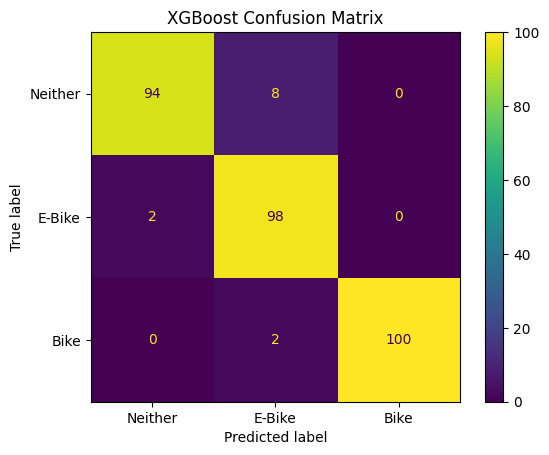

In [9]:
# VIEW XGBOOST CONFUSION MATRIX
labels = ["Neither", "E-Bike", "Bike"]
conf_matrix = confusion_matrix(y, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=labels)
disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

In [10]:
#Sources: https://stackoverflow.com/questions/53782169/random-forest-tuning-with-randomizedsearchcv
# https://medium.com/@thommaskevin/tinyml-xgboost-classifier-795202285779
xgb_params = {
    "colsample_bytree": uniform(0.5, 0.5),
    "gamma": uniform(0, 1),
    "learning_rate": uniform(0.005, 0.5),
    "max_depth": randint(2, 15),
    "n_estimators": randint(50, 300),
    "subsample": uniform(0.4, 0.6),
    "reg_lambda": uniform(0, 10),
    "reg_alpha": uniform(0, 10),
    "min_child_weight": randint(1, 10),
    "colsample_bylevel": uniform(0.5, 0.5),
    "colsample_bynode": uniform(0.5, 0.5),
    "max_delta_step": randint(0, 10),
}
random_search_xgb = RandomizedSearchCV(estimator=xgb_clf, param_distributions=xgb_params, cv=5, scoring='f1_macro', verbose=1, n_iter = 20, random_state=42)

random_search_xgb.fit(X, y)
print("Best XGB parameters found: ", random_search_xgb.best_params_)
print("Best XGB score: ", random_search_xgb.best_score_)
grid_search_score_xgb = random_search_xgb.best_estimator_.score(X, y)

print("Test score XGB: ", grid_search_score_xgb)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


KeyboardInterrupt: 

In [22]:
with open('../XGBClassifier.h', 'w') as file: #THATS what you wanted???
    file.write(port(xgb_clf, tmp_file="C:\\Users\\13038\\Downloads\\CS495_SeniorCapstone\\EBike-Data-Logger\\ESP32-sensor-code\\ESP32-sensor\\FinalXGB.xgb_model.json"))